In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "For sentiment (judgement ⑦) — a subjective 4-class call — how self-consistent is each model, how much do the models agree with each other, and do they track the human coder (Polina)?"

*Judgement ⑦ of 11 · subjective family: no right answer, so the axis is consistency (Krippendorff's nominal alpha), not accuracy. Signal strength (⑧) is analysed separately.*

In [2]:

import json, sys
sys.path.insert(0, r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/scripts")
import compute_alphas as ca

RUNS = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j78_classify_runs.json", encoding="utf-8"))
MAN = RUNS["manifest"]; results = RUNS["results"]; polina = RUNS["polina"]
CAND = MAN["candidate_models"]; K = MAN["k"]; PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.419, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.13, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
MODELS = [m.split("/")[-1] for m in CAND]
def short(m): return m.split("/")[-1]
def nsent(v):
    v = str(v).lower().strip() if v else ""
    return ca.SENT_FIX.get(v, v)

def pivot_alpha(df):
    df = df[df.v.astype(str).str.len() > 0]
    if not len(df):
        return None
    m, _ = ca.pivot_field(df, "v")
    return ca.krippendorff_alpha_nominal(m) if m.size else None

# cross-model long frame (run 0) + Polina
rows = []
for r in results:
    if r["run"] == 0 and not r["parse_failed"]:
        rows.append(dict(coder_id=short(r["model"]), sample_id=r["sample_id"], canonical_drug=r["drug"], v=nsent(r["sentiment"])))
for p in polina:
    rows.append(dict(coder_id="Polina", sample_id=p["sample_id"], canonical_drug=p["drug"], v=nsent(p["sentiment"])))
df = pd.DataFrame(rows); df = df[df.v.astype(str).str.len() > 0]
mo = df[df.coder_id != "Polina"]
mmat, _ = ca.pivot_field(mo, "v"); PANEL = ca.krippendorff_alpha_nominal(mmat) if mmat.size else None
PAIR = ca.pairwise_alphas(mo, "v")
VSP = {md: pivot_alpha(df[df.coder_id.isin([md, "Polina"])]) for md in MODELS}
WITHIN = {}
for m0 in CAND:
    rr = [r for r in results if r["model"] == m0 and not r["parse_failed"]]
    w = pd.DataFrame([dict(coder_id="r%d" % r["run"], sample_id=r["sample_id"], canonical_drug=r["drug"], v=nsent(r["sentiment"])) for r in rr])
    WITHIN[short(m0)] = pivot_alpha(w) if (len(w) and w.coder_id.nunique() >= 2) else None

# per-model sentiment mix (run 0) for the composition view
comp = (pd.DataFrame([dict(m=short(r["model"]), s=nsent(r["sentiment"])) for r in results
                      if r["run"] == 0 and not r["parse_failed"] and nsent(r["sentiment"])]))

def _f(x): return f"{x:.2f}" if (x is not None and x == x) else "n/a"
_vp = pd.Series({k: v for k, v in VSP.items() if v is not None})
display(Markdown(f"""
**Abstract.** Sentiment (⑦) has no clean right answer, so we measure consistency, not accuracy, across
**{len(MODELS)} models** on the **{MAN['n_pairs']}** Polina-labelled (post, drug) pairs (k={K}, temp 0).
**Within-model** self-agreement is very high (median nominal α **{_f(pd.Series(WITHIN).median())}**) — at
temperature 0 the call is near-deterministic, so run-to-run noise is not the issue. The real story is
**cross-model**: the roster's panel α is **{_f(PANEL)}** — moderate agreement, well short of 1, so models
genuinely diverge on the 4-class call. Against **Polina** the median α is **{_f(_vp.median())}**
(best {_vp.idxmax()} {_f(_vp.max())}). Read all of it with the caveat that **agreement is diagnostic, never
validation**: where the roster agrees it may simply share our prompt's bias — and the confirmed ~10–20%
positive over-call is exactly such a shared error, invisible as disagreement.
"""))



**Abstract.** Sentiment (⑦) has no clean right answer, so we measure consistency, not accuracy, across
**22 models** on the **116** Polina-labelled (post, drug) pairs (k=3, temp 0).
**Within-model** self-agreement is very high (median nominal α **0.94**) — at
temperature 0 the call is near-deterministic, so run-to-run noise is not the issue. The real story is
**cross-model**: the roster's panel α is **0.64** — moderate agreement, well short of 1, so models
genuinely diverge on the 4-class call. Against **Polina** the median α is **0.52**
(best claude-sonnet-4.6 0.78). Read all of it with the caveat that **agreement is diagnostic, never
validation**: where the roster agrees it may simply share our prompt's bias — and the confirmed ~10–20%
positive over-call is exactly such a shared error, invisible as disagreement.


## 1. Why sentiment is measured by consistency, not accuracy

Sentiment (positive / negative / mixed / neutral) is interpretive — there is no external truth to check it against, and an Opus judge would only reproduce the same interpretive bias. So instead of accuracy we ask three consistency questions with Krippendorff's α: does a model agree with **itself** across repeats, with the **other models**, and with the **human coder**? The caveat that governs all three: high agreement can mean the call is easy *or* that everyone inherited our prompt's bias — it is a diagnostic, never a verdict of correctness.

## 2. Within-model consistency — is the call stable at temperature 0?

First, each model against itself across the K repeats. At temperature 0 this should be near-perfect; where it isn't, sentiment is intrinsically unstable for that model.

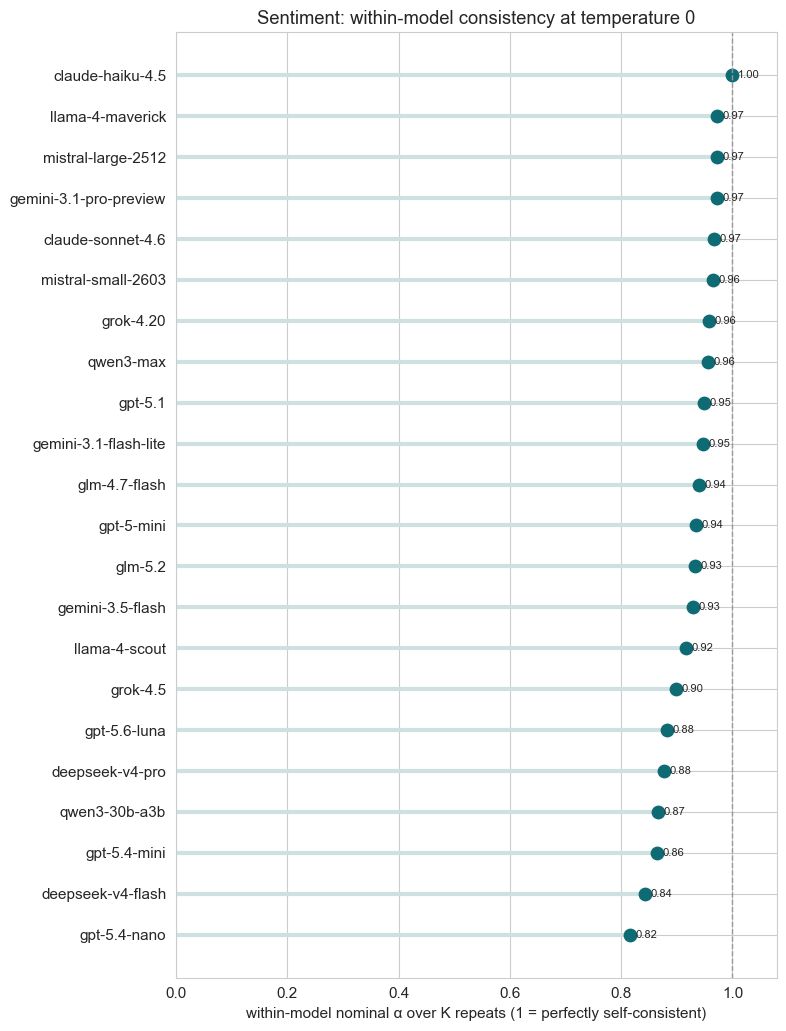

**What this shows:** within-model agreement is high (median **0.94**) — at temperature 0 the sentiment call is close to deterministic, so run-to-run noise is small. The variability that matters lives *between* models (§3), not within them.

In [3]:

w = pd.DataFrame({"mshort": MODELS, "a": [WITHIN.get(m) for m in MODELS]}).dropna().sort_values("a")
ys = np.arange(len(w))
fig, ax = plt.subplots(figsize=(8, 1.2 + 0.42*len(w)))
ax.hlines(ys, 0, w.a, color="#cfe0e1", lw=3, zorder=1)
ax.scatter(w.a, ys, color="#0e6b74", s=80, zorder=2)
for y, v in zip(ys, w.a):
    ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=8)
ax.axvline(1.0, ls="--", color="#999", lw=1)
ax.set_yticks(ys); ax.set_yticklabels(w.mshort); ax.set_xlim(min(0, w.a.min()-0.05), 1.08)
ax.set_xlabel("within-model nominal α over K repeats (1 = perfectly self-consistent)")
ax.set_title("Sentiment: within-model consistency at temperature 0"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** within-model agreement is high (median **{w.a.median():.2f}**) — at temperature 0 the "
  f"sentiment call is close to deterministic, so run-to-run noise is small. The variability that matters lives "
  f"*between* models (§3), not within them."))


## 3. Cross-model agreement — do the models agree on sentiment?

Now the models against each other (one run each). The heatmap is pairwise α between every pair; the panel α (all at once) is the headline. This says who behaves alike — not who is right.

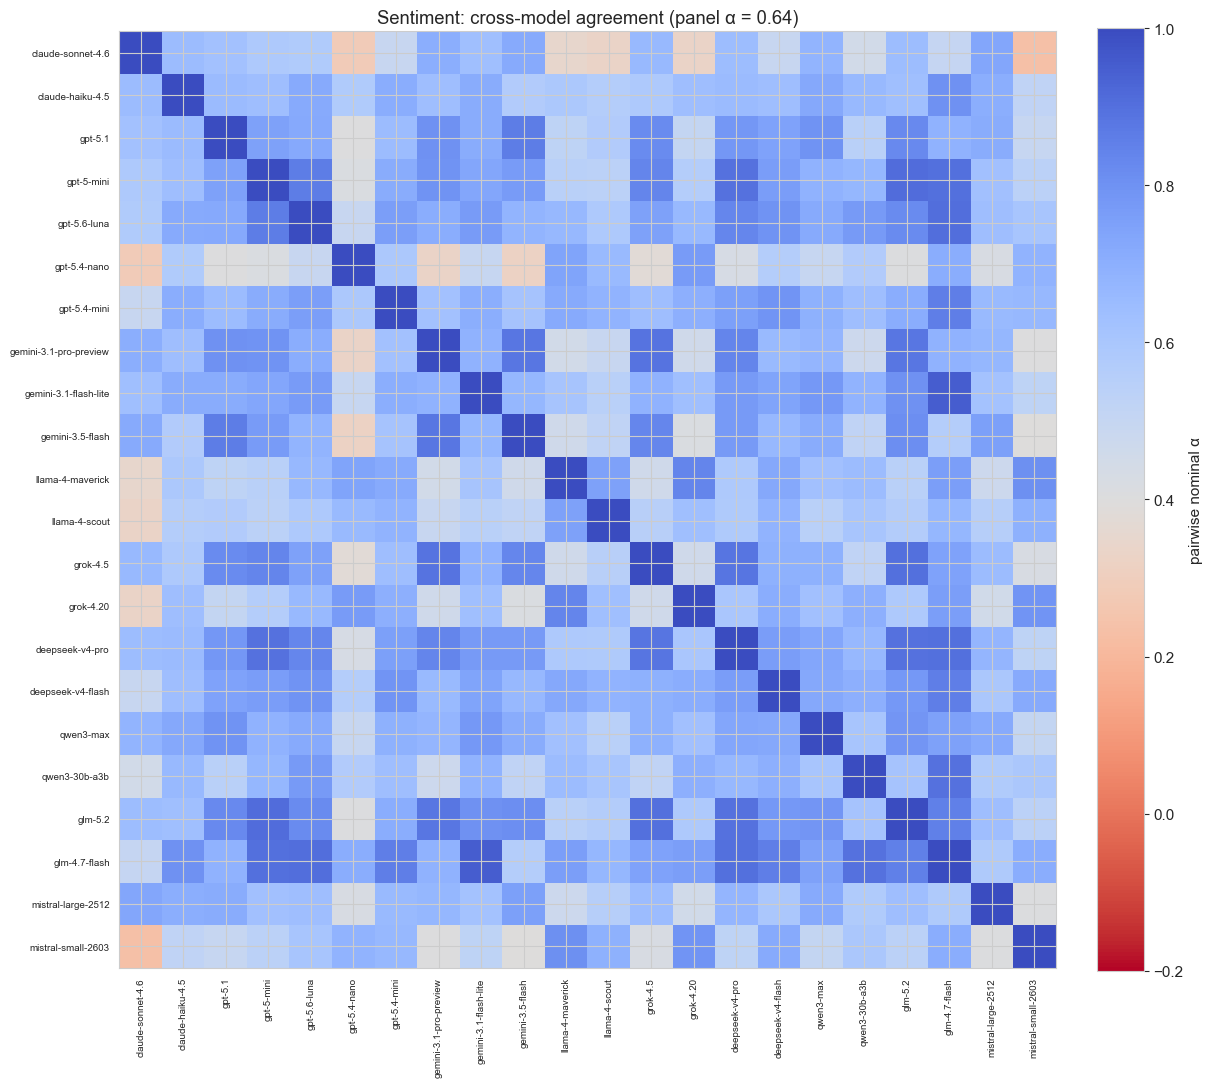

**What this shows:** panel α **0.64** — moderate, well below 1: models diverge on the 4-class call, not just at the margin. The biggest outlier is **gpt-5.4-nano** (1 − mean pairwise = 0.49); the most typical is **glm-4.7-flash**. But an outlier is only 'wrong' if it *also* diverges from the human (§4) — divergence alone doesn't say who's right.

In [4]:

order = MODELS
M = PAIR.reindex(index=order, columns=order).astype(float)
fig, ax = plt.subplots(figsize=(0.42*len(order)+3, 0.42*len(order)+2))
im = ax.imshow(M.values, cmap="coolwarm_r", vmin=-0.2, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="pairwise nominal α")
ax.set_title(f"Sentiment: cross-model agreement (panel α = {PANEL:.2f})")
fig.tight_layout(); plt.show()
# outlier = 1 - mean pairwise
out = {m: 1 - np.nanmean([PAIR.loc[m,o] for o in order if o != m]) for m in order}
od = pd.Series(out).sort_values(ascending=False)
display(Markdown(
  f"**What this shows:** panel α **{PANEL:.2f}** — moderate, well below 1: models diverge on the 4-class call, "
  f"not just at the margin. The biggest outlier is **{od.index[0]}** (1 − mean pairwise = {od.iloc[0]:.2f}); the "
  f"most typical is **{od.index[-1]}**. But an outlier is only 'wrong' if it *also* diverges from the human "
  f"(§4) — divergence alone doesn't say who's right."))


## 4. Agreement with the human coder (Polina)

Each model against Polina's 116 labels. Higher α = tracks the human better — but read it as a **screen**, not a ranking: Polina's codebook was lifted from the same prompt, so this measures spec-compliance, not correctness.

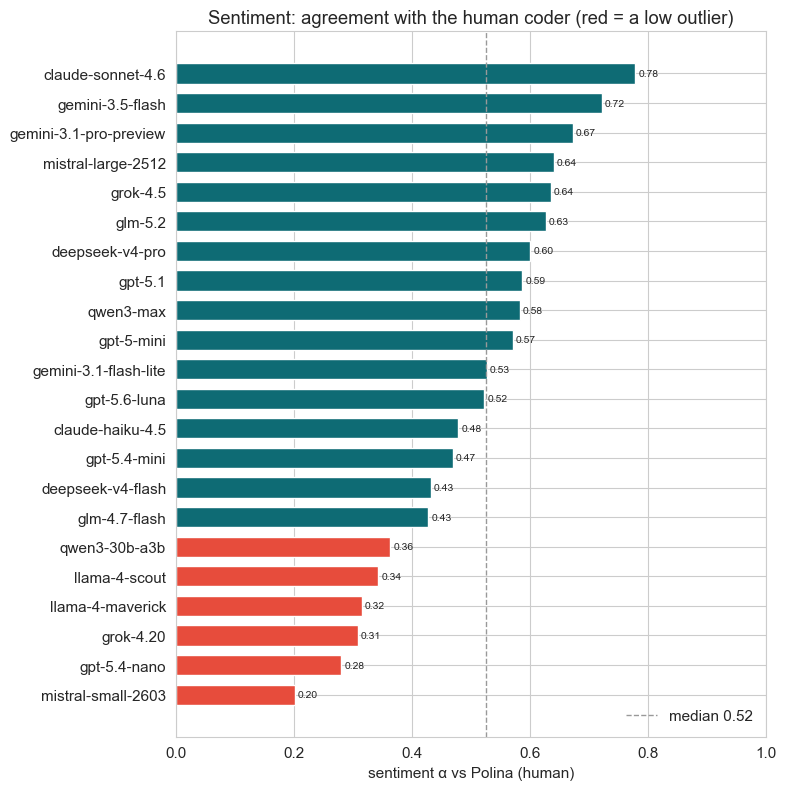

**What this shows:** models cluster around α **0.52** with Polina — the best is **claude-sonnet-4.6** (0.78), the low outlier **mistral-small-2603** (0.20). This screens out a model that codes sentiment wildly differently from a human; it does **not** rank who is 'correct', because Polina and the models were both handed the same rubric.

In [5]:

vp = pd.DataFrame({"mshort": MODELS, "a": [VSP.get(m) for m in MODELS]}).dropna().sort_values("a")
fig, ax = plt.subplots(figsize=(8, 0.32*len(vp)+1))
colors = ["#e74c3c" if v < vp.a.median()-0.1 else "#0e6b74" for v in vp.a]
ax.barh(vp.mshort, vp.a, color=colors, height=0.68)
for y,(_,r) in enumerate(vp.iterrows()): ax.text(r.a + 0.005, y, f"{r.a:.2f}", va="center", fontsize=7.5)
ax.axvline(vp.a.median(), ls="--", color="#999", lw=1, label=f"median {vp.a.median():.2f}")
ax.set_xlim(min(0, vp.a.min()-0.05), 1.0); ax.set_xlabel("sentiment α vs Polina (human)")
ax.set_title("Sentiment: agreement with the human coder (red = a low outlier)")
ax.legend(frameon=False, loc="lower right"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** models cluster around α **{vp.a.median():.2f}** with Polina — the best is "
  f"**{vp.iloc[-1].mshort}** ({vp.iloc[-1].a:.2f}), the low outlier **{vp.iloc[0].mshort}** ({vp.iloc[0].a:.2f}). "
  f"This screens out a model that codes sentiment wildly differently from a human; it does **not** rank who is "
  f"'correct', because Polina and the models were both handed the same rubric."))


## 5. The one probe that could push past agreement — the permutation null

Consistency can't tell whether sentiment is actually **drug-conditional** or just reads generic positivity in the post. The test that can (no gold needed): re-run sentiment asking about drug *X* on posts that are really about drug *Y*. If the 'helped' rate doesn't collapse toward the base rate under that permutation, the model isn't reading the drug — it's reading the vibe. **This permuted pass is not in this run — it is the recommended next step for ⑦**, and the single most informative check we can add without labels.

## 6. Conclusion & scorecard

The consistency scorecard for sentiment — within-model, vs-Polina, divergence. No accuracy column, by design.

In [6]:

order = MODELS
rows = []
for m in order:
    div = 1 - np.nanmean([PAIR.loc[m,o] for o in order if o != m])
    rows.append(dict(model=m, within=WITHIN.get(m), vs_polina=VSP.get(m), divergence=div,
                     price=PRICES.get(next(c for c in CAND if c.split('/')[-1]==m), np.nan)))
SC = pd.DataFrame(rows).sort_values("vs_polina", ascending=False)
show = SC.copy()
for c in ["within","vs_polina","divergence"]: show[c] = show[c].round(2)
show["price"] = show["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
show.columns = ["model","within-model α","vs Polina α","divergence","$/1M in"]
display(HTML("<b>⑦ sentiment — consistency scorecard</b>" + show.to_html(index=False)))
lines = [
  f"- **Within-model is a non-issue at temp 0** (median α {pd.Series(WITHIN).median():.2f}).",
  f"- **Cross-model agreement caps at panel α {PANEL:.2f}** — sentiment is moderately, not strongly, agreed; "
  f"the roster genuinely splits on the 4-class call.",
  f"- **vs-Polina is a screen** (median {SC.vs_polina.median():.2f}) — it flags outliers, not who is right.",
  f"- **No model is 'correct' on sentiment.** It is validated only to consistency, and the shared positive "
  f"over-call sits underneath every number here. The permutation null (§5) is the next step to probe whether "
  f"sentiment is drug-conditional at all.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


model,within-model α,vs Polina α,divergence,$/1M in
claude-sonnet-4.6,0.97,0.78,0.46,$3
gemini-3.5-flash,0.93,0.72,0.36,$1.5
gemini-3.1-pro-preview,0.97,0.67,0.35,$2
mistral-large-2512,0.97,0.64,0.39,$0.5
grok-4.5,0.90,0.64,0.33,$2
glm-5.2,0.93,0.63,0.28,$0.419
deepseek-v4-pro,0.88,0.60,0.28,$0.435
gpt-5.1,0.95,0.59,0.32,$1.25
qwen3-max,0.96,0.58,0.32,$0.78
gpt-5-mini,0.94,0.57,0.30,$0.25


### Verdict

- **Within-model is a non-issue at temp 0** (median α 0.94).
- **Cross-model agreement caps at panel α 0.64** — sentiment is moderately, not strongly, agreed; the roster genuinely splits on the 4-class call.
- **vs-Polina is a screen** (median 0.52) — it flags outliers, not who is right.
- **No model is 'correct' on sentiment.** It is validated only to consistency, and the shared positive over-call sits underneath every number here. The permutation null (§5) is the next step to probe whether sentiment is drug-conditional at all.

## 7. Research limitations

- **Agreement ≠ validity** — the defining limit of a subjective judgement. Shared prompt bias inflates
  agreement; the confirmed ~10–20% positive over-call is a shared error that does not show up as disagreement.
- **Polina is one contaminated-codebook coder** (116 labels, codebook lifted from the prompt), so vs-Polina is
  a screen for outliers, not a human-agreement ceiling. Per-class cells (neutral 5, mixed 16) are too small for
  per-class scoring.
- **The permutation null is not in this run** (§5) — it is the recommended next probe for ⑦.
- **K=3 repeats** — enough to show within-model stability at temp 0, not to estimate it tightly.
- Measures consistency of a measurement step, not any treatment effect.

In [7]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
prov = pd.DataFrame({
  "item": ["run generated (UTC)","judgement","candidate models","reference","pairs / k","temperature","alpha impl","skill version"],
  "value": [MAN["generated_utc"], "7_sentiment", len(CAND), MAN["reference"], f'{MAN["n_pairs"]} / {MAN["k"]}',
            MAN["temperature"], "compute_alphas.py (nominal)", "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the consistency of a measurement pipeline, not population-level treatment '
             'effects. This is not medical advice.</div>'))


item,value
run generated (UTC),2026-07-18T02:08:00.613127+00:00
judgement,7_sentiment
candidate models,22
reference,human_coder_a (Polina)
pairs / k,116 / 3
temperature,0.0
alpha impl,compute_alphas.py (nominal)
skill version,research-assistant v2
